# Importar datos

[Daily Climate time series data](https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data)

In [2]:
import kagglehub

path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\efrai\.cache\kagglehub\datasets\sumanthvrao\daily-climate-time-series-data\versions\3


In [3]:
from pathlib import Path

files_list = list(Path(path).glob('**/*'))
files_list

[WindowsPath('C:/Users/efrai/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3/DailyDelhiClimateTest.csv'),
 WindowsPath('C:/Users/efrai/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3/DailyDelhiClimateTrain.csv')]

In [4]:
file_dict = {file.stem: file for file in files_list if file.is_file()}
display(file_dict)

{'DailyDelhiClimateTest': WindowsPath('C:/Users/efrai/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3/DailyDelhiClimateTest.csv'),
 'DailyDelhiClimateTrain': WindowsPath('C:/Users/efrai/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3/DailyDelhiClimateTrain.csv')}

In [5]:
import pandas as pd

df = pd.read_csv(file_dict['DailyDelhiClimateTrain'])

print(df.shape)
df.head()

(1462, 5)


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


# Objetivo
Entrenar una red neuronal que pueda predecir la temperatura del siguiente día en los siguientes rangos:
- `< 14`
- `14 a 22`
- `22 a 27`
- `27 a 33`
- `> 33`

# Análisis exploratorio
Convertir `date` a fecha

In [6]:
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by='date', ascending=True, inplace=True)
df.set_index('date', inplace=True)

df.sample(5)

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2015-01-27,13.250000,74.250000,5.337500,1019.333333
2015-10-14,28.125000,63.625000,4.875000,1013.250000
2014-07-11,36.625000,38.625000,8.787500,996.125000
2013-11-30,17.875000,69.625000,11.812500,1015.875000
2016-10-01,32.541667,61.916667,3.170833,1007.500000


Falta alguna fecha?

In [7]:
df.index.diff().value_counts(dropna=False)

date
1 days    1461
NaT          1
Name: count, dtype: int64

Distribución de los años

In [8]:
df['year'] = df.index.year
display(df['year'].value_counts(normalize=False, dropna=False, sort=False))

df.head()

year
2013    365
2014    365
2015    365
2016    366
2017      1
Name: count, dtype: int64

,meantemp,humidity,wind_speed,meanpressure,year
date,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013
2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013
2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013
2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013
2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013


Quitamos el día de 2017

In [9]:
df = df[df['year'] != 2017].copy()
display(df['year'].value_counts(normalize=False, dropna=False, sort=False))

year
2013    365
2014    365
2015    365
2016    366
Name: count, dtype: int64

Cómo se distribuye cada variable?

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for plotting multiple features
df_melted = df.melt(id_vars=['year'], var_name='feature', value_name='value')

df_melted.sample(5)

,year,feature,value
4897,2014,meanpressure,999.571429
2557,2016,humidity,75.875000
2450,2015,humidity,58.375000
5264,2015,meanpressure,1003.250000
1879,2014,humidity,80.000000


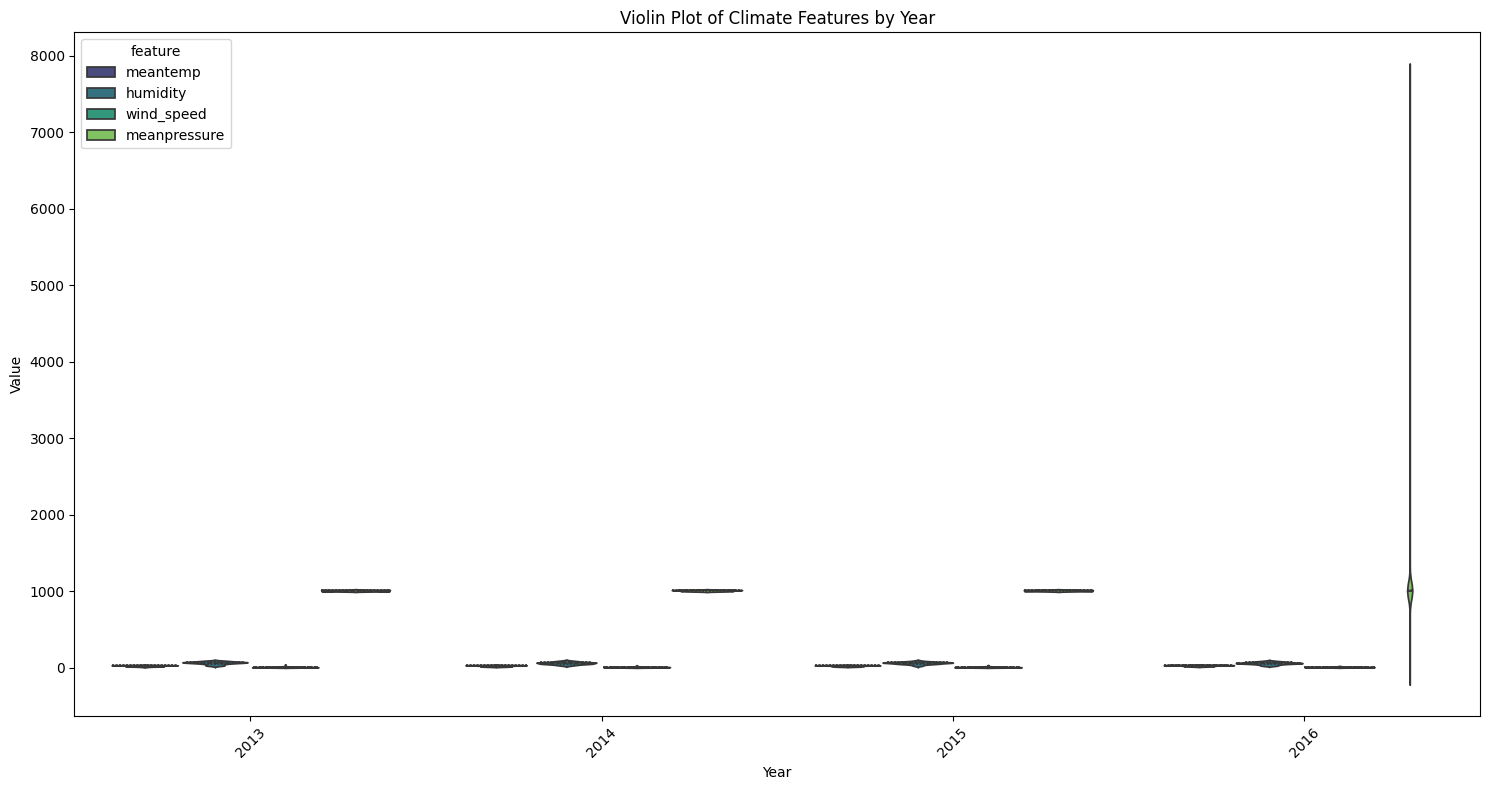

In [11]:
# Create the violin plot
plt.figure(figsize=(15, 8))
sns.violinplot(data=df_melted, x='year', y='value', hue='feature', inner='quartile', palette='viridis')
plt.title('Violin Plot of Climate Features by Year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Isolation Forest

In [12]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination='auto', random_state=42)

df['anomaly_score'] = model.fit_predict(df) == -1

df['anomaly_score'].value_counts(normalize=True, dropna=False)

anomaly_score
False    0.787817
True     0.212183
Name: proportion, dtype: float64

Cómo se ven los outliers?

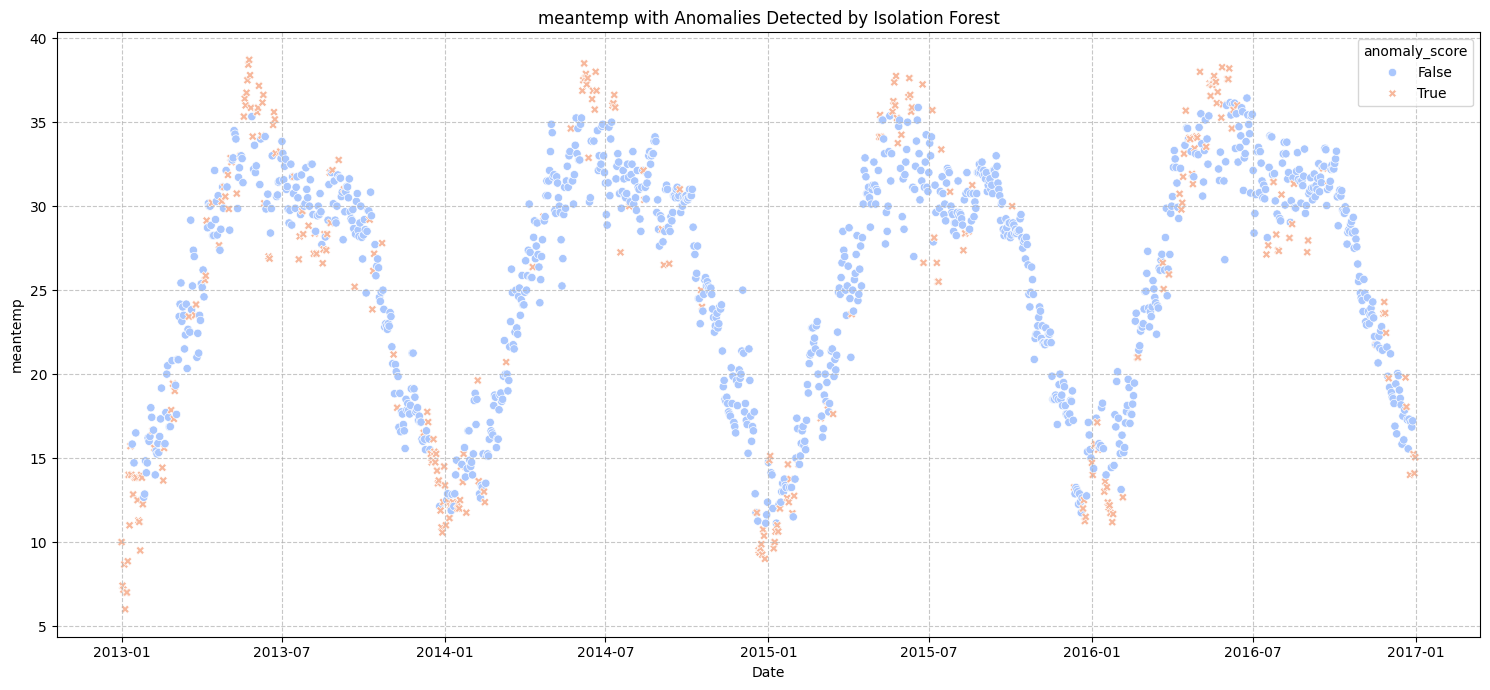

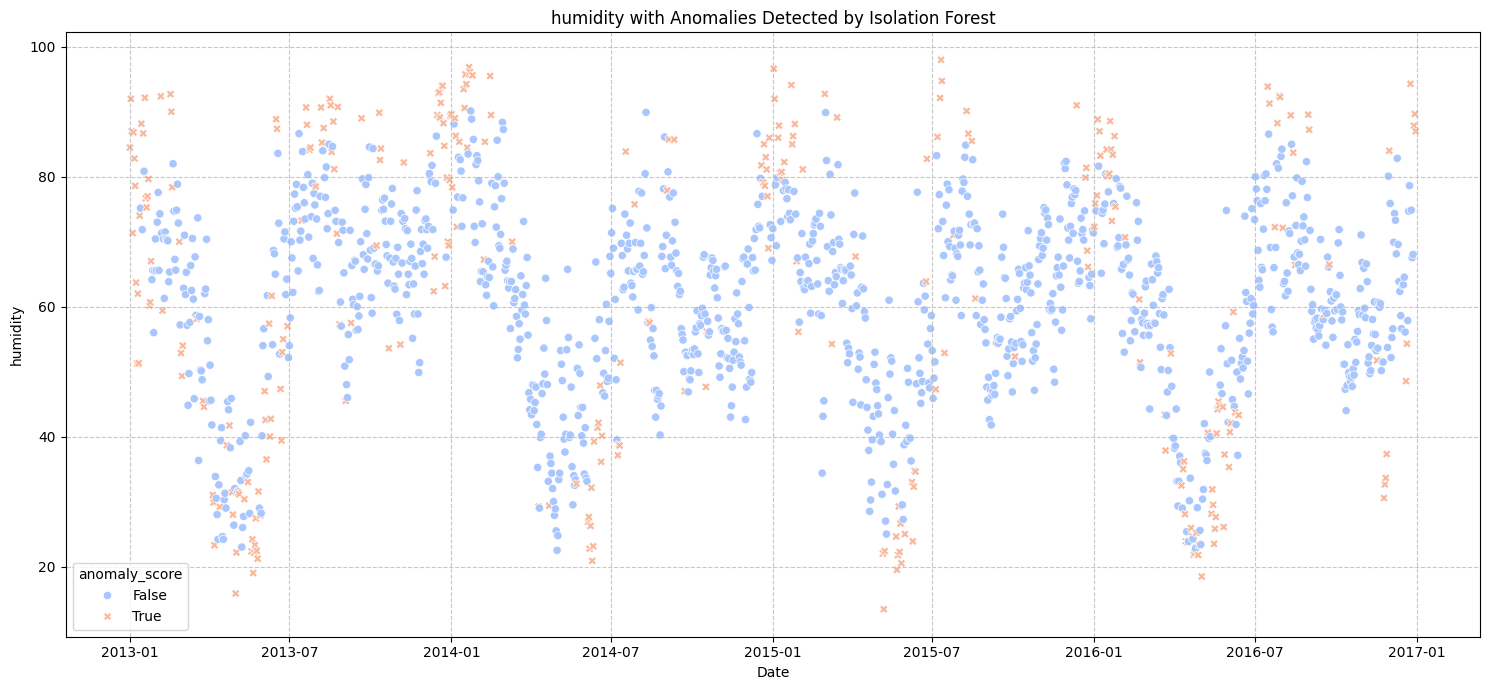

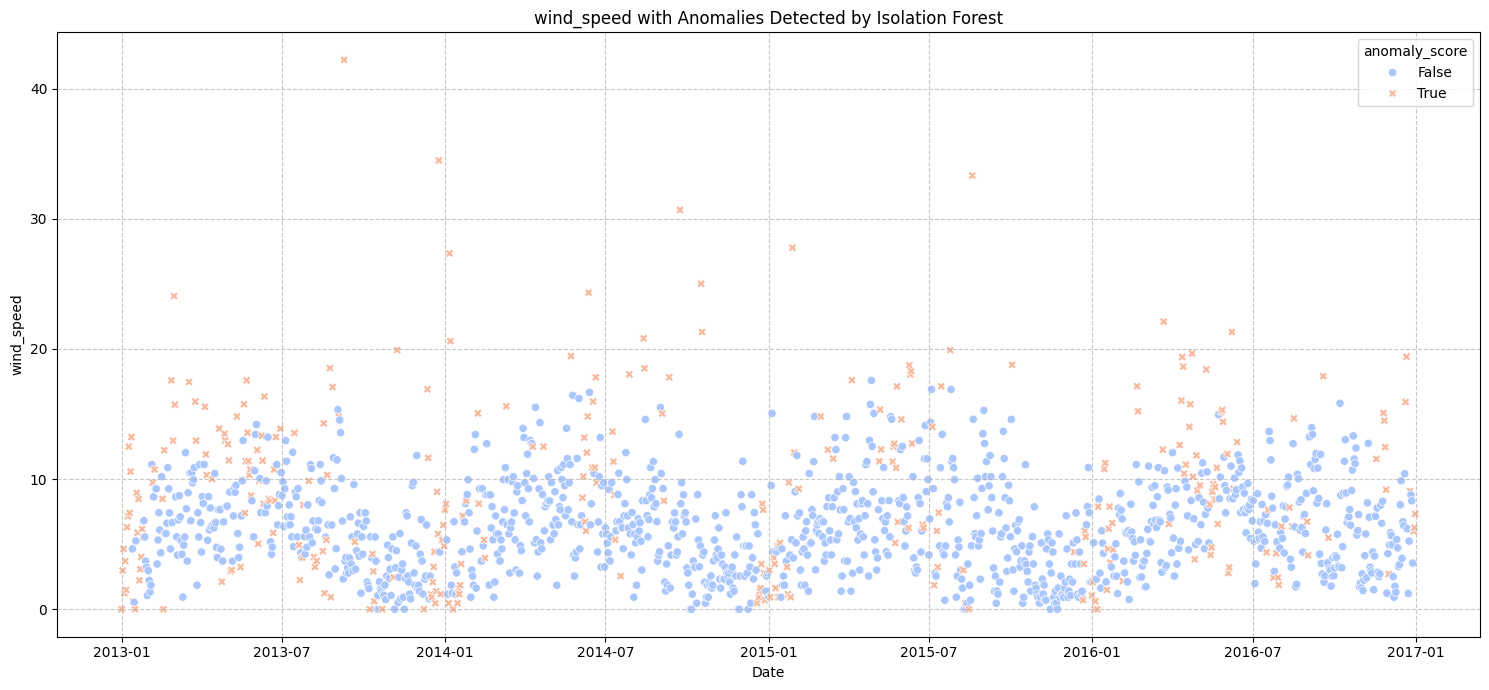

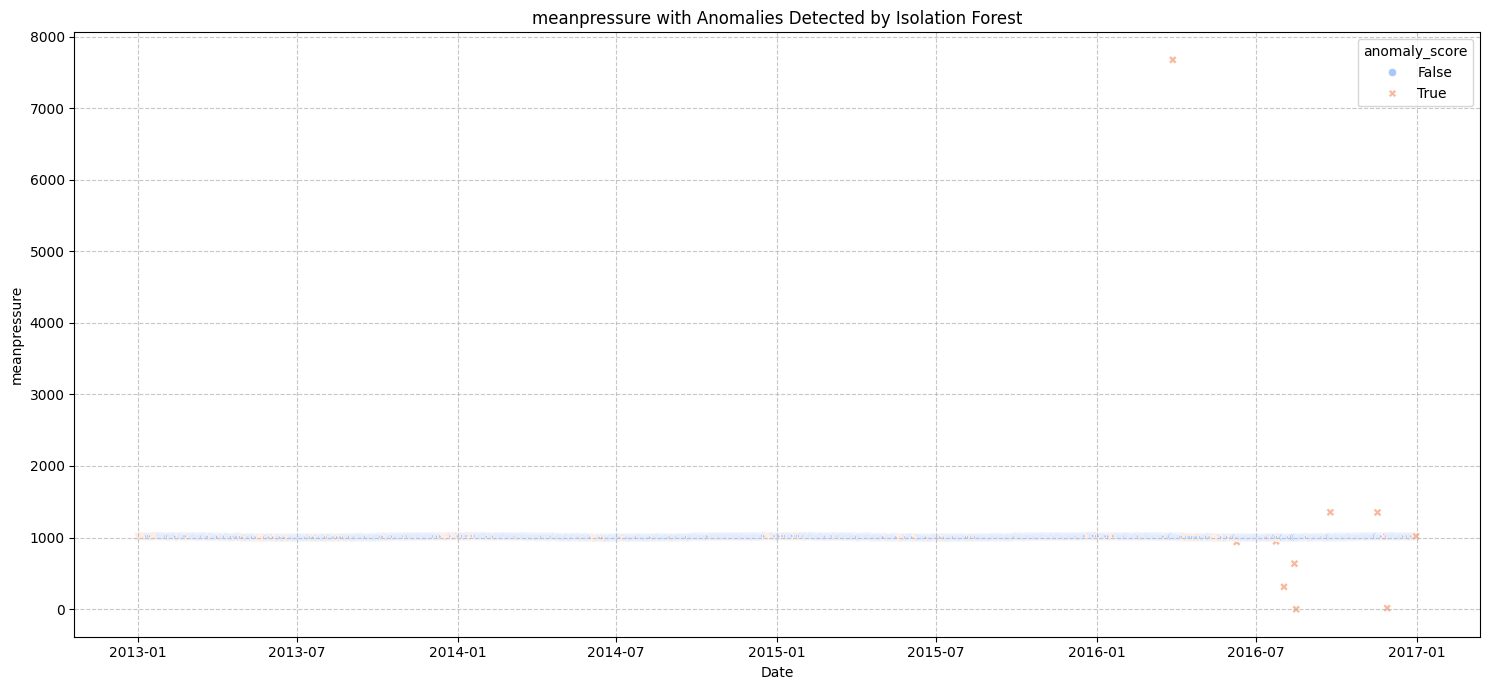

In [13]:
features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

for col in features:
    plt.figure(figsize=(15, 7))
    sns.scatterplot(data=df.reset_index(), x='date', y=col, hue='anomaly_score', style='anomaly_score', palette='coolwarm')
    plt.title(f'{col} with Anomalies Detected by Isolation Forest')
    plt.xlabel('Date')
    plt.ylabel(f'{col}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

`meanpressure` es el problema principal

<Axes: >

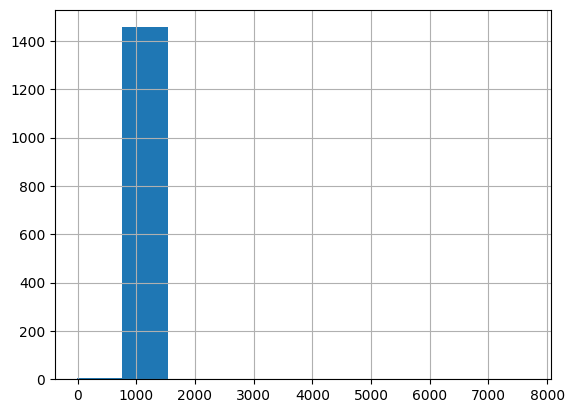

In [14]:
df['meanpressure'].hist()

<Axes: >

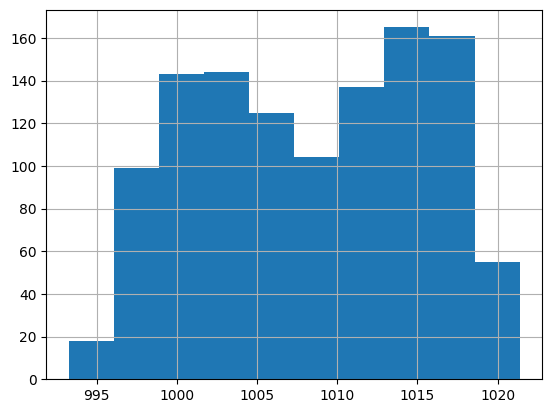

In [15]:
df[~df['anomaly_score']]['meanpressure'].hist()

Isolation Forest sólo para `meanpressure`

In [16]:
from sklearn.ensemble import IsolationForest

model_meanpressure = IsolationForest(contamination=0.01, random_state=42)

df['meanpressure_anomaly'] = model_meanpressure.fit_predict(df[['meanpressure']]) == -1

print('Value counts for meanpressure_anomaly:')
display(df['meanpressure_anomaly'].value_counts())

display(df.sample(5))

Value counts for meanpressure_anomaly:


meanpressure_anomaly
False    1446
True       15
Name: count, dtype: int64

,meantemp,humidity,wind_speed,meanpressure,year,anomaly_score,meanpressure_anomaly
date,,,,,,,
2013-05-27,35.857143,31.571429,8.728571,999.142857,2013,True,False
2013-10-17,26.857143,76.714286,1.057143,1010.428571,2013,False,False
2016-11-26,24.294118,32.647059,14.494118,1013.250000,2016,True,False
2016-08-13,30.321429,77.071429,3.229630,1001.071429,2016,False,False
2014-08-24,33.125000,46.250000,11.350000,1002.875000,2014,False,False


Cómo se ve la variable sin outliers?

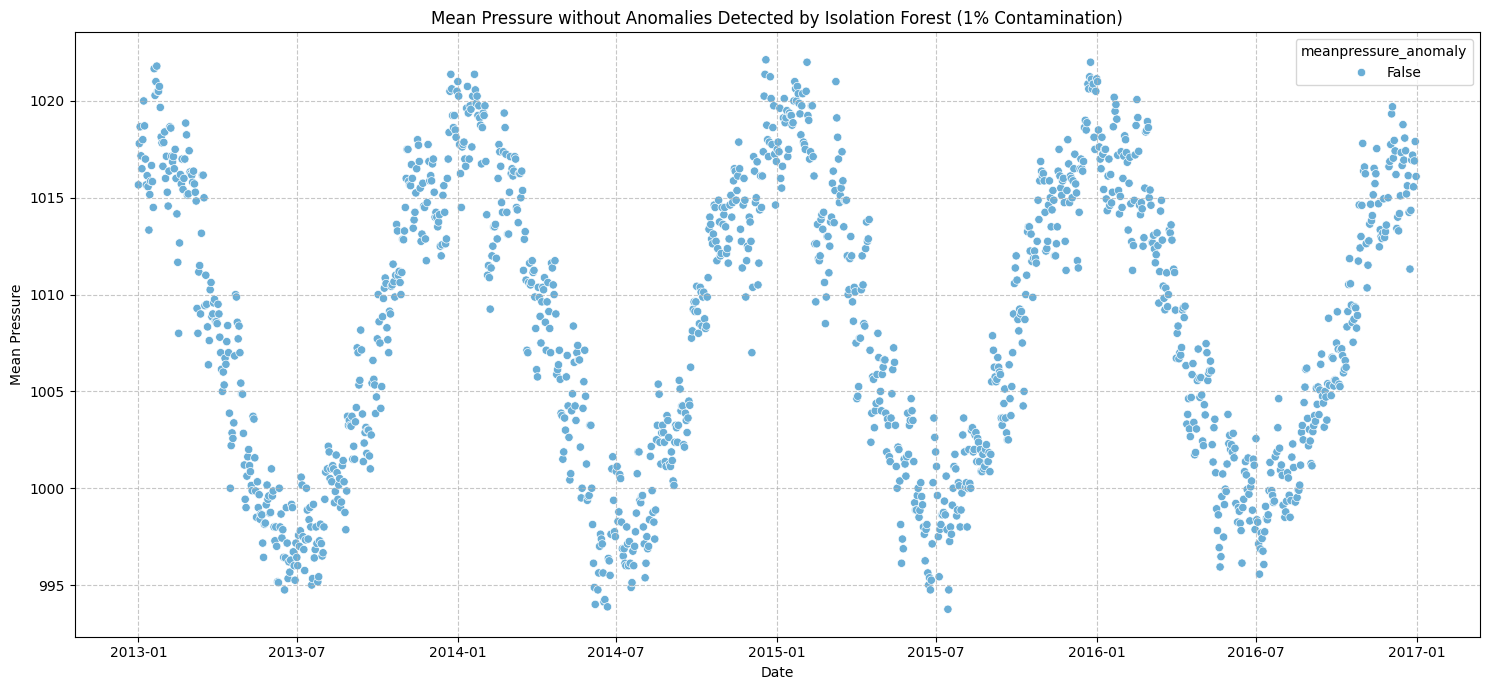

In [17]:
plt.figure(figsize=(15, 7))
sns.scatterplot(data=df[~df['meanpressure_anomaly']].reset_index(), x='date', y='meanpressure', hue='meanpressure_anomaly', style='meanpressure_anomaly', palette='Blues')
plt.title('Mean Pressure without Anomalies Detected by Isolation Forest (1% Contamination)')
plt.xlabel('Date')
plt.ylabel('Mean Pressure')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Vamos a ajustar los outliers mediante Interpolación Temporal

Dado que el dataset es una serie temporal diaria con alta autocorrelación ($AR(1) \approx 0.975$), las lecturas fuera de los límites físicos plausibles en superficie para Delhi ($[950, 1050]\text{ hPa}$) corresponden a fallos de sensor aislados.

In [18]:
import numpy as np

display(df['meanpressure'].describe())

pressure_anomalies_mask = ~df['meanpressure'].between(950, 1050)
print(f"Anomalías detectadas en 'meanpressure': {pressure_anomalies_mask.sum()}")
display(df.loc[pressure_anomalies_mask, ['meanpressure']])

count    1461.000000
mean     1011.101197
std       180.293335
min        -3.041667
25%      1001.571429
50%      1008.555556
75%      1014.937500
max      7679.333333
Name: meanpressure, dtype: float64

Anomalías detectadas en 'meanpressure': 9


,meanpressure
date,
2016-03-28,7679.333333
2016-06-09,938.066667
2016-07-24,946.312500
2016-08-02,310.437500
2016-08-14,633.900000
2016-08-16,-3.041667
2016-09-24,1352.615385
2016-11-17,1350.296296
2016-11-28,12.045455


Se sustituyen estas anomalías por `NaN` y se sobreescriben mediante interpolación lineal temporal (`interpolate(method='time')`), preservando la inercia física del clima.

In [19]:
df.loc[pressure_anomalies_mask, 'meanpressure'] = np.nan
print(f'Nulls in meanpressure: {df["meanpressure"].isna().sum()}')

Nulls in meanpressure: 9


In [20]:
# 4. Imputar mediante interpolación temporal lineal
df['meanpressure'] = df['meanpressure'].interpolate(method='time')

# 5. Estadísticas descriptivas tras la imputación
print("\nEstadísticas de 'meanpressure' tras la imputación:")
display(df['meanpressure'].describe())


Estadísticas de 'meanpressure' tras la imputación:


count    1461.000000
mean     1008.244547
std         7.437207
min       991.375000
25%      1001.625000
50%      1008.555556
75%      1014.875000
max      1023.000000
Name: meanpressure, dtype: float64

Ahora sí. Cómo queda `meanpressure` ajustada?

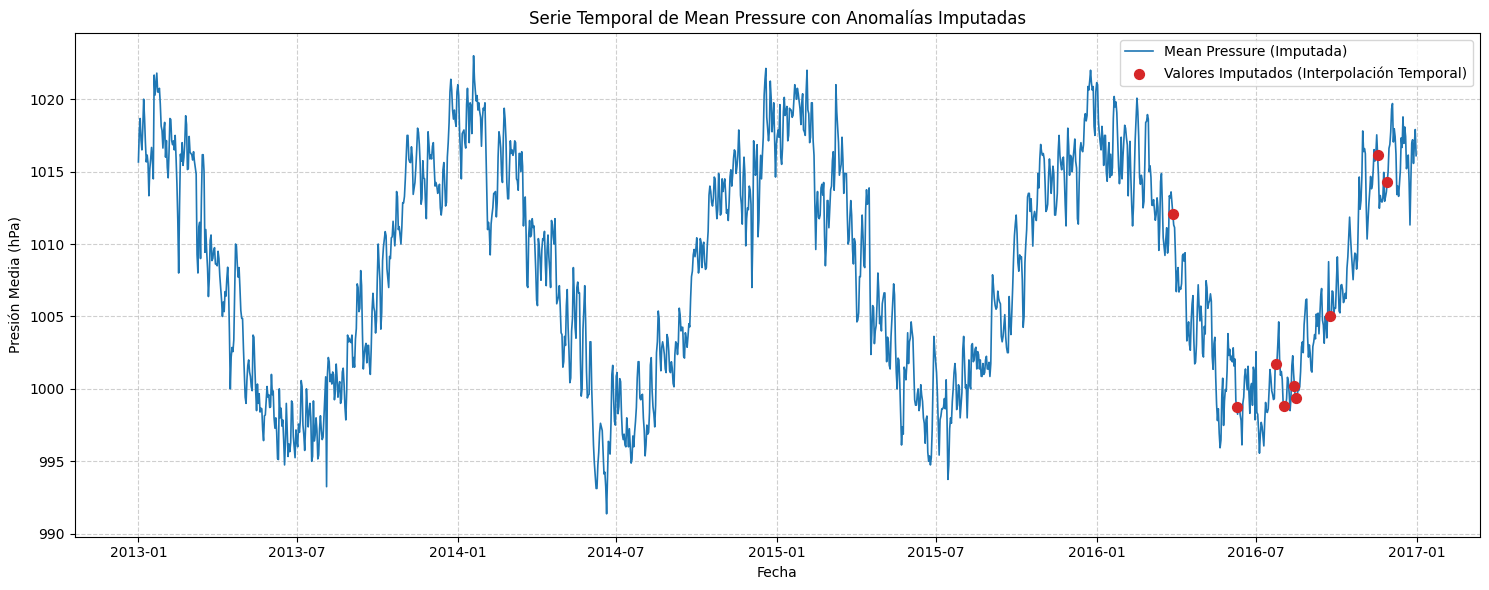

In [21]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['meanpressure'], color='#1f77b4', linewidth=1.2, label='Mean Pressure (Imputada)')
plt.scatter(df.index[pressure_anomalies_mask], df.loc[pressure_anomalies_mask, 'meanpressure'], 
            color='#d62728', s=50, zorder=5, label='Valores Imputados (Interpolación Temporal)')
plt.title('Serie Temporal de Mean Pressure con Anomalías Imputadas')
plt.xlabel('Fecha')
plt.ylabel('Presión Media (hPa)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Y ahora sí, vamos a ver la distribución anual de cada variable

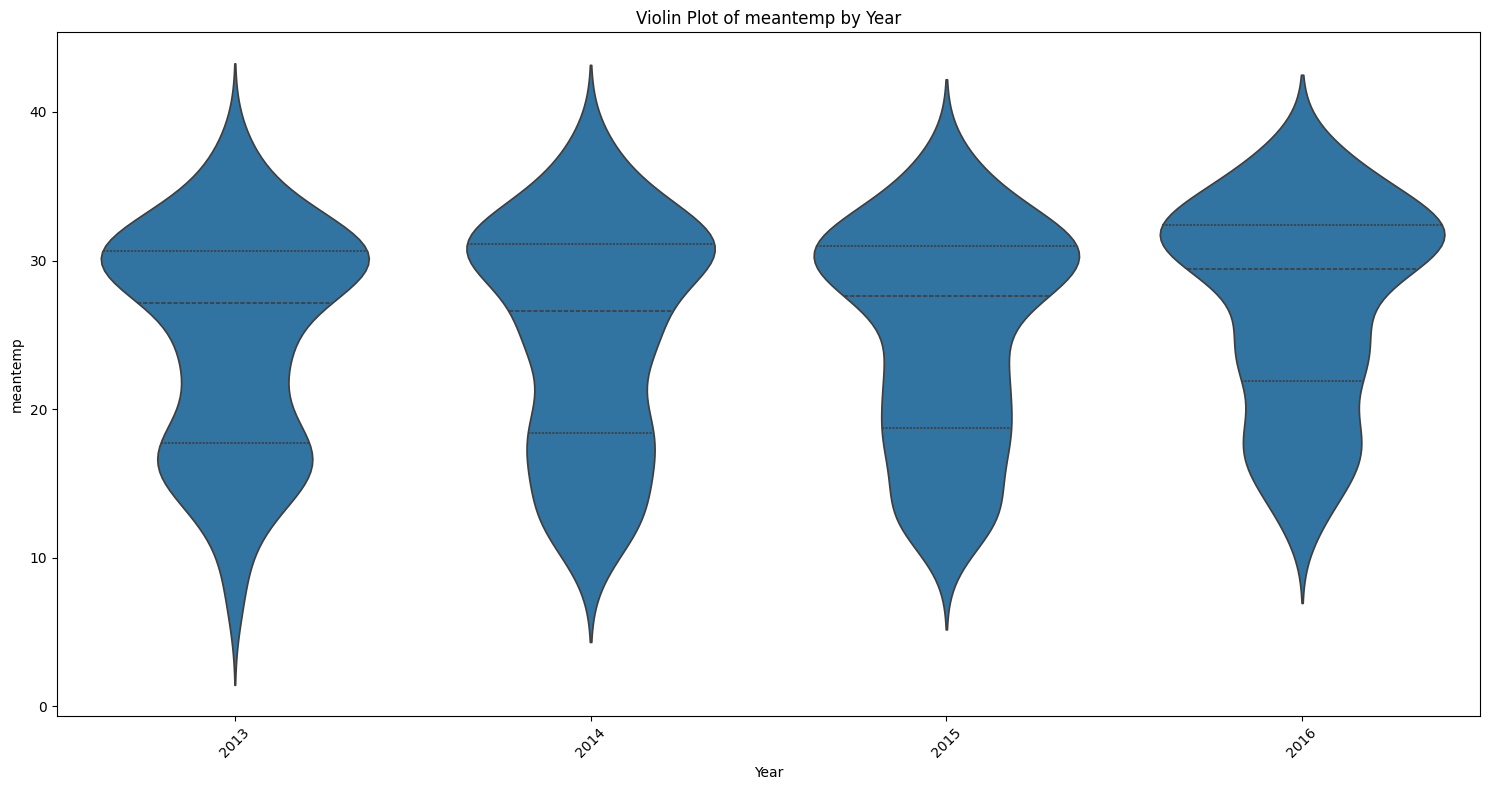

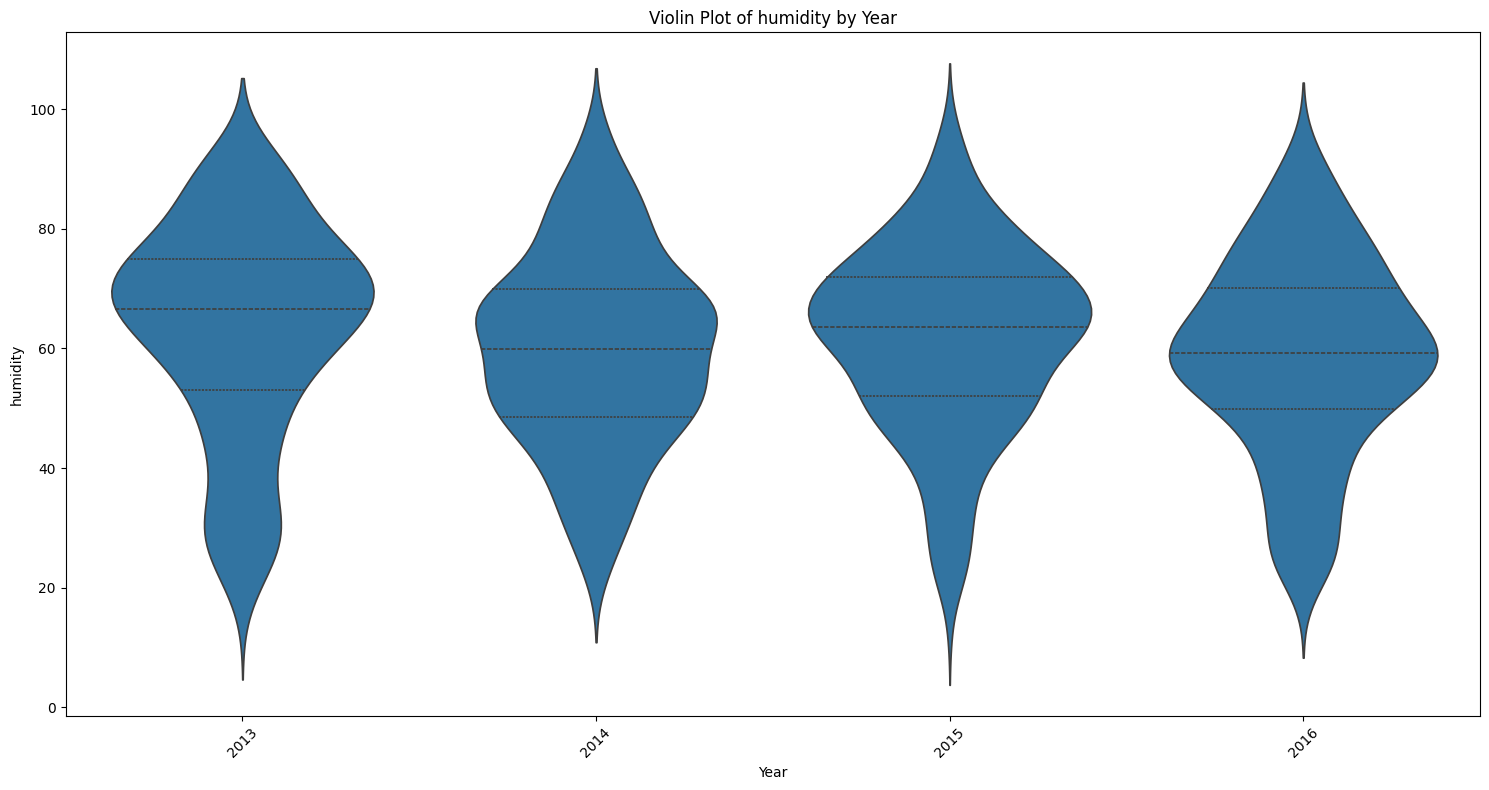

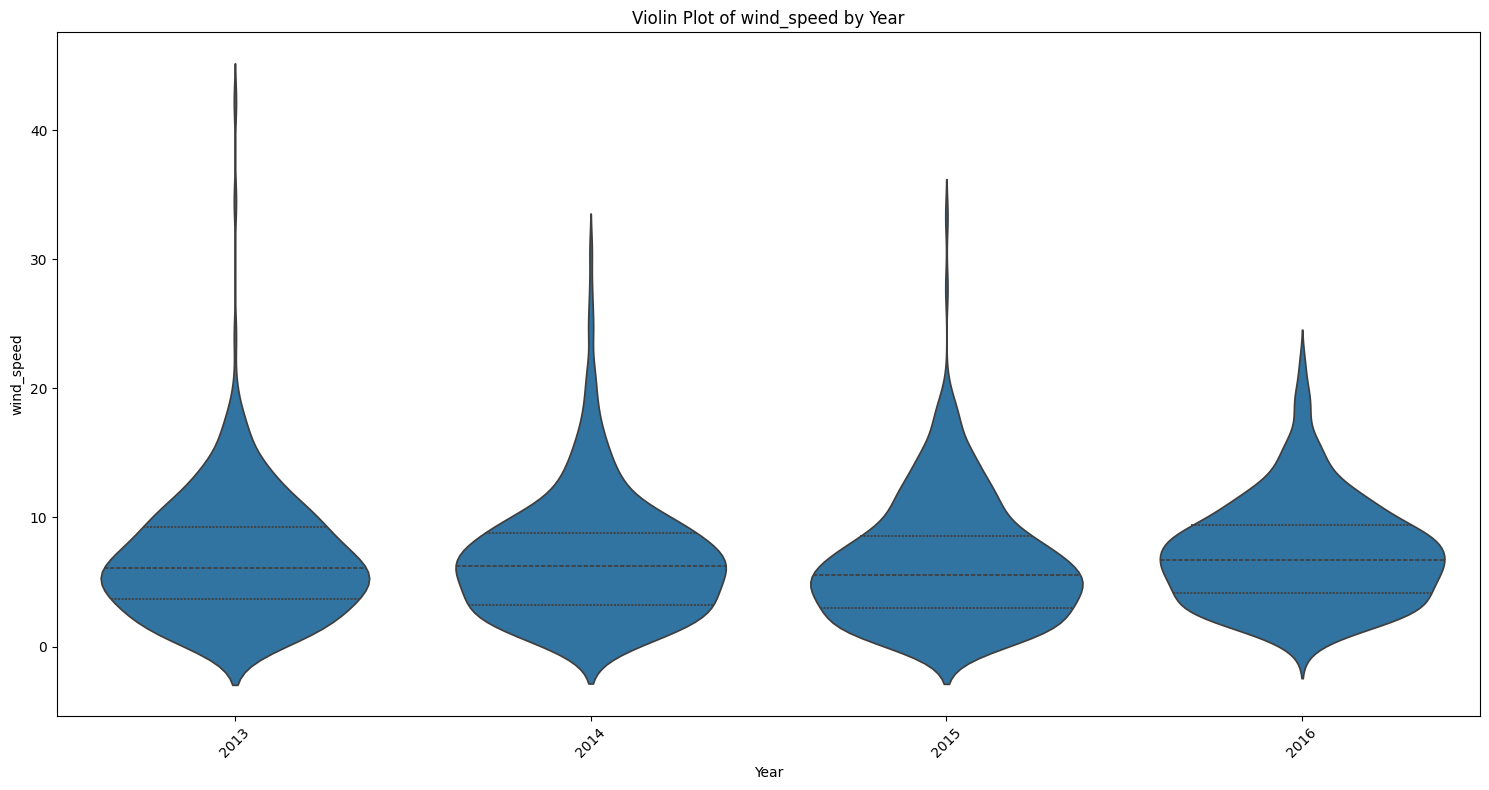

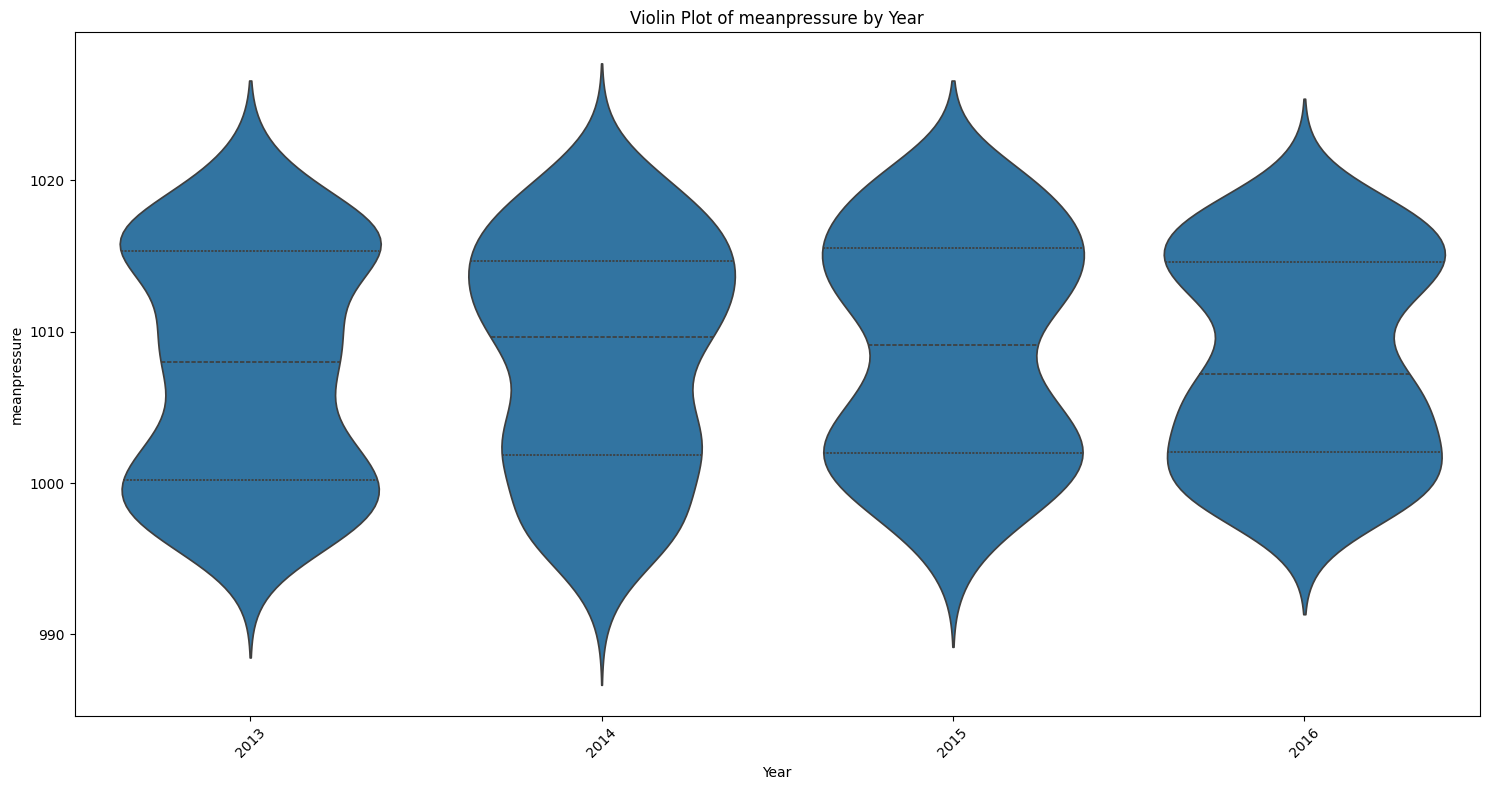

In [22]:
for col in features:
    plt.figure(figsize=(15, 8))
    sns.violinplot(data=df, x='year', y=col, inner='quartile')
    plt.title(f'Violin Plot of {col} by Year')
    plt.xlabel('Year')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Ingeniería de variables

In [23]:
def engineer_weather_features(df_in):
    df_out = df_in.copy()
    
    # 1. Presión de vapor de agua e (hPa) y Sensación Térmica (°C)
    # Ecuación de Steadman / Australian Bureau of Meteorology
    e = (df_out['humidity'] / 100.0) * 6.105 * np.exp((17.27 * df_out['meantemp']) / (237.7 + df_out['meantemp']))
    wind_ms = df_out['wind_speed'] / 3.6
    df_out['apparent_temp'] = df_out['meantemp'] + 0.33 * e - 0.70 * wind_ms - 4.00
    
    # 2. Estacionalidad solar continua (Día del Año - DOY)
    doy = df_out.index.dayofyear
    df_out['sin_doy'] = np.sin(2 * np.pi * doy / 365.25)
    df_out['cos_doy'] = np.cos(2 * np.pi * doy / 365.25)
    
    # 3. Tendencias de temperatura (Deltas de 1 y 7 días)
    df_out['temp_diff_1'] = df_out['meantemp'].diff(1)
    df_out['temp_diff_7'] = df_out['meantemp'].diff(7)
    
    # 4. Medias móviles
    df_out['temp_ma_7'] = df_out['meantemp'].rolling(7).mean()
    df_out['temp_ma_14'] = df_out['meantemp'].rolling(14).mean()
    
    return df_out

# Aplicar ingeniería de variables a train y a test combinado (con buffer histórico)
df = engineer_weather_features(df)

df.sample(5)

,meantemp,humidity,wind_speed,meanpressure,year,anomaly_score,meanpressure_anomaly,apparent_temp,sin_doy,cos_doy,temp_diff_1,temp_diff_7,temp_ma_7,temp_ma_14
date,,,,,,,,,,,,,,
2014-08-20,33.250000,47.125000,8.787500,1002.375000,2014,False,False,35.445491,-0.750864,-0.660457,0.250000,1.125000,31.632653,31.190276
2016-05-16,37.214286,23.500000,9.020000,1000.800000,2016,True,False,36.364447,0.706727,-0.707487,-0.035714,3.680952,35.742272,34.530490
2014-09-10,28.750000,77.500000,4.875000,1003.250000,2014,False,False,33.866329,-0.935835,-0.352439,-2.250000,0.125000,29.267857,29.173469
2013-02-15,19.166667,65.333333,10.183333,1011.666667,2013,False,False,17.961681,0.711276,0.702913,1.833333,5.166667,16.381803,16.377041
2015-09-29,29.000000,54.571429,9.528571,1010.571429,2015,False,False,30.337023,-0.999445,-0.033324,0.750000,-1.250000,28.655612,29.677296


## Shift

Queremos saber cómo fue el clima X días antes

In [24]:
(
    df[['meantemp']]
    .shift(range(5))
    .head(15)
    .style.background_gradient(cmap='Blues', axis=None)
    .format(precision=2, na_rep="-")
)

,meantemp_0,meantemp_1,meantemp_2,meantemp_3,meantemp_4
date,,,,,
2013-01-01 00:00:00,10.00,-,-,-,-
2013-01-02 00:00:00,7.40,10.00,-,-,-
2013-01-03 00:00:00,7.17,7.40,10.00,-,-
2013-01-04 00:00:00,8.67,7.17,7.40,10.00,-
2013-01-05 00:00:00,6.00,8.67,7.17,7.40,10.00
2013-01-06 00:00:00,7.00,6.00,8.67,7.17,7.40
2013-01-07 00:00:00,7.00,7.00,6.00,8.67,7.17
2013-01-08 00:00:00,8.86,7.00,7.00,6.00,8.67
2013-01-09 00:00:00,14.00,8.86,7.00,7.00,6.00


In [25]:
features

['meantemp', 'humidity', 'wind_speed', 'meanpressure']

In [26]:
features.extend(
    ['apparent_temp', 'sin_doy', 'cos_doy',
    'temp_diff_1', 'temp_diff_7', 'temp_ma_7', 'temp_ma_14']
)

features

['meantemp',
 'humidity',
 'wind_speed',
 'meanpressure',
 'apparent_temp',
 'sin_doy',
 'cos_doy',
 'temp_diff_1',
 'temp_diff_7',
 'temp_ma_7',
 'temp_ma_14']

In [27]:
X = df[features].shift(range(30)).dropna()

X.head()

,meantemp_0,humidity_0,wind_speed_0,meanpressure_0,apparent_temp_0,sin_doy_0,cos_doy_0,temp_diff_1_0,temp_diff_7_0,temp_ma_7_0,...,humidity_29,wind_speed_29,meanpressure_29,apparent_temp_29,sin_doy_29,cos_doy_29,temp_diff_1_29,temp_diff_7_29,temp_ma_7_29,temp_ma_14_29
date,,,,,,,,,,,,,,,,,,,,,
2013-02-12,15.333333,70.333333,7.416667,1017.500000,13.926380,0.674069,0.738668,-0.541667,-1.291667,15.450510,...,88.166667,0.616667,1015.166667,13.015700,0.238513,0.971139,-3.000000,5.833333,13.176871,10.390816
2013-02-13,16.285714,70.142857,6.085714,1016.000000,15.379039,0.686676,0.726964,0.952381,-0.380952,15.396088,...,71.857143,0.528571,1015.857143,14.573298,0.255182,0.966893,1.880952,5.857143,14.013605,10.727551
2013-02-14,17.333333,63.833333,4.333333,1014.166667,16.649871,0.699079,0.715044,1.047619,1.733333,15.643707,...,86.666667,0.000000,1016.666667,14.347073,0.271777,0.962360,-0.880952,-0.166667,13.989796,11.187075
2013-02-15,19.166667,65.333333,10.183333,1011.666667,17.961681,0.711276,0.702913,1.833333,5.166667,16.381803,...,80.833333,5.250000,1015.833333,16.475239,0.288291,0.957543,2.666667,5.500000,14.775510,11.853741
2013-02-16,14.428571,92.714286,8.485714,1008.000000,13.796960,0.723262,0.690574,-4.738095,-1.000000,16.238946,...,92.166667,8.950000,1014.500000,12.893244,0.304719,0.952442,-2.666667,-1.880952,14.506803,12.222789


<Axes: >

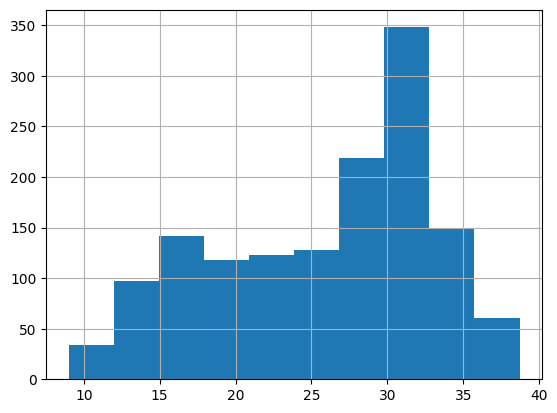

In [28]:
y = X['meantemp_0']
y.hist()

In [29]:
# Filtrar X eliminando el lag 0 (conservando los 29 lags pasados completos: 116 columnas)
X = X.drop(columns=X.filter(regex='_0$').columns)

X.head()

,meantemp_1,humidity_1,wind_speed_1,meanpressure_1,apparent_temp_1,sin_doy_1,cos_doy_1,temp_diff_1_1,temp_diff_7_1,temp_ma_7_1,...,humidity_29,wind_speed_29,meanpressure_29,apparent_temp_29,sin_doy_29,cos_doy_29,temp_diff_1_29,temp_diff_7_29,temp_ma_7_29,temp_ma_14_29
date,,,,,,,,,,,,,,,,,,,,,
2013-02-12,15.875000,70.500000,5.325000,1016.500000,15.026950,0.661263,0.750154,0.625000,-1.553571,15.635034,...,88.166667,0.616667,1015.166667,13.015700,0.238513,0.971139,-3.000000,5.833333,13.176871,10.390816
2013-02-13,15.333333,70.333333,7.416667,1017.500000,13.926380,0.674069,0.738668,-0.541667,-1.291667,15.450510,...,71.857143,0.528571,1015.857143,14.573298,0.255182,0.966893,1.880952,5.857143,14.013605,10.727551
2013-02-14,16.285714,70.142857,6.085714,1016.000000,15.379039,0.686676,0.726964,0.952381,-0.380952,15.396088,...,86.666667,0.000000,1016.666667,14.347073,0.271777,0.962360,-0.880952,-0.166667,13.989796,11.187075
2013-02-15,17.333333,63.833333,4.333333,1014.166667,16.649871,0.699079,0.715044,1.047619,1.733333,15.643707,...,80.833333,5.250000,1015.833333,16.475239,0.288291,0.957543,2.666667,5.500000,14.775510,11.853741
2013-02-16,19.166667,65.333333,10.183333,1011.666667,17.961681,0.711276,0.702913,1.833333,5.166667,16.381803,...,92.166667,8.950000,1014.500000,12.893244,0.304719,0.952442,-2.666667,-1.880952,14.506803,12.222789


### Entrenar
Separar train y val

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

scaler = PowerTransformer()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

X_train_scaled.shape, X_val_scaled.shape

((1135, 319), (284, 319))

In [31]:
y_train.shape, y_val.shape

((1135,), (284,))

Crear Datasets y DataLoaders

In [32]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(
    TensorDataset(
        torch.as_tensor(X_train_scaled, dtype=torch.float32),
        torch.as_tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    ),
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    TensorDataset(
        torch.as_tensor(X_val_scaled, dtype=torch.float32),
        torch.as_tensor(y_val.values, dtype=torch.float32).view(-1, 1)
    ),
    batch_size=64,
    shuffle=False,
    num_workers=0
)

Definir arquitectura

In [33]:
import torchmetrics
from torch import nn
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

# Fijar semilla de reproducibilidad
pl.seed_everything(42)

class WeatherRegression(pl.LightningModule):
    def __init__(self, in_features, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        # HuberLoss: penalización suave ante valores extremos reales
        self.criterion = nn.HuberLoss(delta=1.5)
        
        # Arquitectura Sequential
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.criterion(preds, y)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.criterion(preds, y)
        mae = torch.mean(torch.abs(preds - y))
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_mae', mae, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        x, y = batch
        return self(x)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=4
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
            },
        }

Seed set to 42


In [34]:
model = WeatherRegression(in_features=X_train_scaled.shape[1], lr=1e-3)
model

WeatherRegression(
  (criterion): HuberLoss()
  (net): Sequential(
    (0): Linear(in_features=319, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

Callbacks

In [35]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min', verbose=True)
checkpoint = ModelCheckpoint(
    monitor='val_loss', 
    mode='min', 
    save_top_k=1, 
    filename='best_regression_weather-{epoch:02d}-{val_loss:.3f}'
)

trainer = pl.Trainer(
    max_epochs=80,
    callbacks=[early_stop, checkpoint],
    accelerator='auto',
    enable_progress_bar=True
)

trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion │ HuberLoss  │      0 │ train │     0 │
│ 1 │ net       │ Sequential │ 51.8 K │ train │     0 │
└───┴───────────┴────────────┴────────┴───────┴───────┘

Trainable params: 51.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 51.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

c:\Users\efrai\OneDrive\Desktop\EF\Academic\Professor\DL 
classes\uag-deep-learning\.venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.

...

Metric val_loss improved by 0.028 >= min_delta = 0.0. New best score: 1.629


Metric val_loss improved by 0.032 >= min_delta = 0.0. New best score: 1.597


Metric val_loss improved by 0.062 >= min_delta = 0.0. New best score: 1.535


Metric val_loss improved by 0.201 >= min_delta = 0.0. New best score: 1.334


Monitored metric val_loss did not improve in the last 10 records. Best score: 1.334. Signaling Trainer to stop.


Importar el mejor modelo

In [36]:
best_reg_path = checkpoint.best_model_path
best_model = WeatherRegression.load_from_checkpoint(
    best_reg_path,
    weights_only=True
)

best_model.eval()

WeatherRegression(
  (criterion): HuberLoss()
  (net): Sequential(
    (0): Linear(in_features=319, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [37]:
device = next(best_model.parameters()).device
best_model.to(device)

device

device(type='cuda', index=0)

Predecir en val

In [38]:
preds_batches = trainer.predict(best_model, dataloaders=val_loader)
y_pred = torch.cat(preds_batches).view(-1).cpu().numpy()
y_true = y_val.values.reshape(-1)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\efrai\OneDrive\Desktop\EF\Academic\Professor\DL classes\uag-deep-learning\.venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


# Resultados

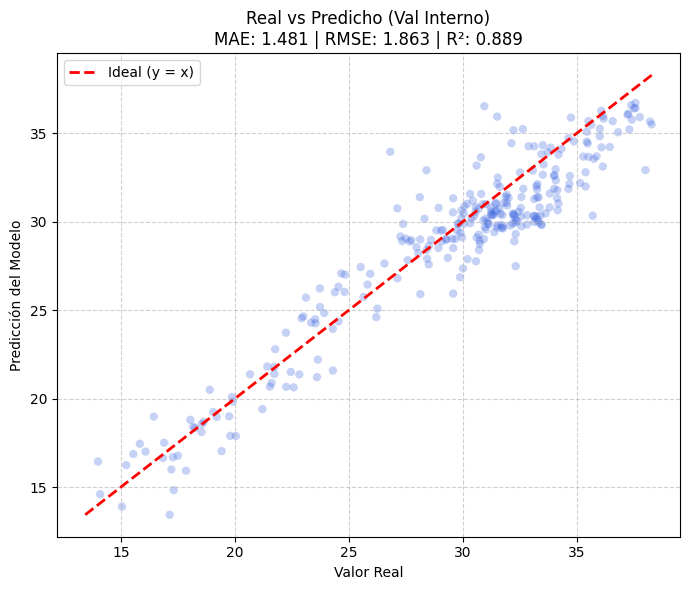

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.scatter(y_true, y_pred, alpha=0.3, edgecolors='none', color='royalblue')

# Línea de identidad ideal (y = x)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (y = x)')

plt.title(f'Real vs Predicho (Val Interno)\nMAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f}')
plt.xlabel('Valor Real')
plt.ylabel('Predicción del Modelo')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


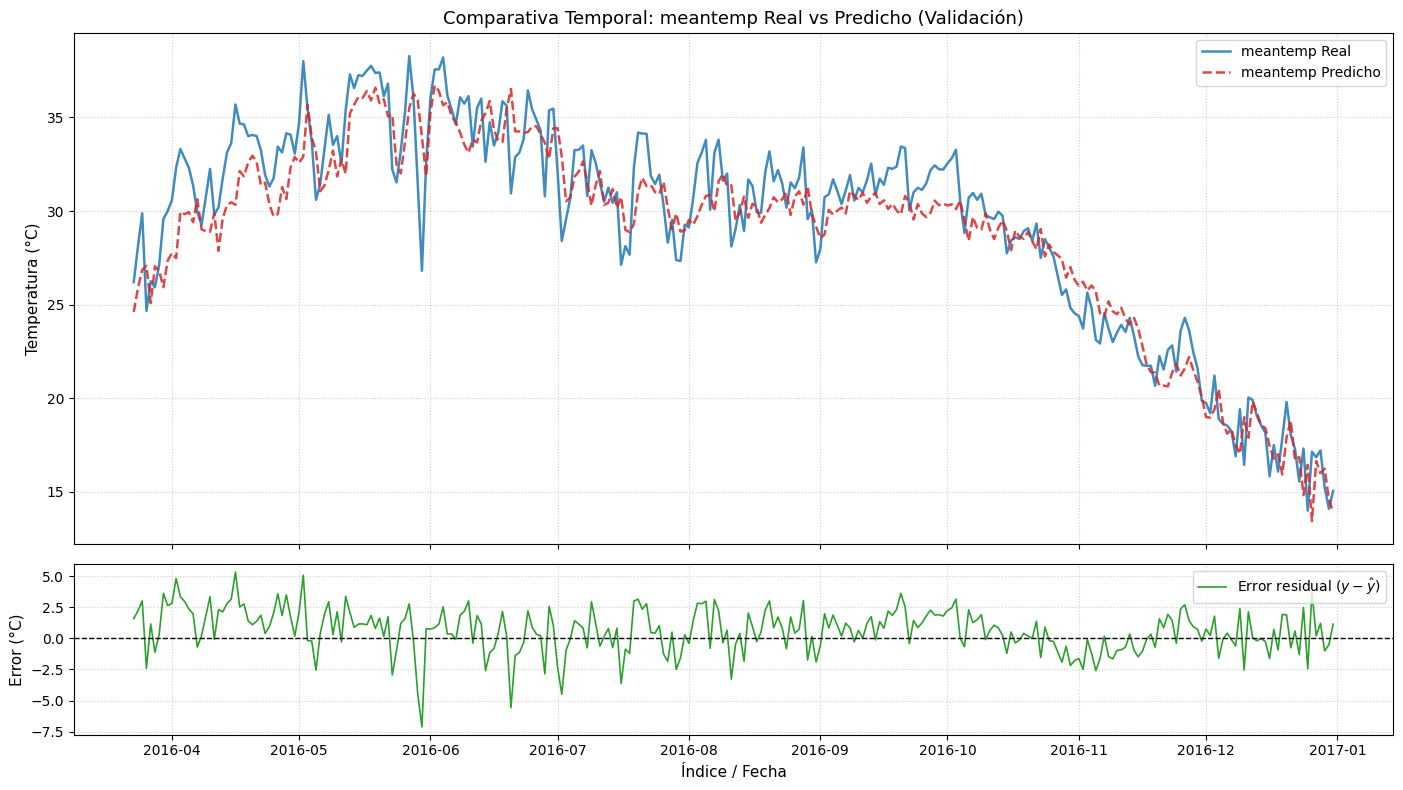

In [40]:
# Si y_val conserva su índice original (fechas o índices ordenados)
indices = y_val.index if hasattr(y_val, 'index') else np.arange(len(y_true))
residuos = y_true - y_pred

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Gráfica principal: Secuencia Real vs Predicción ---
ax1.plot(indices, y_true, label='meantemp Real', color='#1f77b4', lw=1.8, alpha=0.85)
ax1.plot(indices, y_pred, label='meantemp Predicho', color='#d62728', lw=1.8, linestyle='--', alpha=0.85)
ax1.set_ylabel('Temperatura (°C)', fontsize=11)
ax1.set_title('Comparativa Temporal: meantemp Real vs Predicho (Validación)', fontsize=13)
ax1.legend(loc='upper right', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Gráfica secundaria: Residuos (Error de predicción) ---
ax2.plot(indices, residuos, color='#2ca02c', lw=1.2, label='Error residual ($y - \hat{y}$)')
ax2.axhline(0, color='black', linestyle='--', lw=1)
ax2.set_xlabel('Índice / Fecha', fontsize=11)
ax2.set_ylabel('Error (°C)', fontsize=11)
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()



CLASSIFICATION REPORT (DISCRETIZADO DESDE REGRESIÓN)
              precision    recall  f1-score   support

        < 14     0.0000    0.0000    0.0000         0
     14 a 22     0.8571    0.9231    0.8889        39
     22 a 27     0.8000    0.6250    0.7018        32
     27 a 33     0.7333    0.9098    0.8121       133
        > 33     0.8200    0.5125    0.6308        80

    accuracy                         0.7676       284
   macro avg     0.6421    0.5941    0.6067       284
weighted avg     0.7823    0.7676    0.7591       284



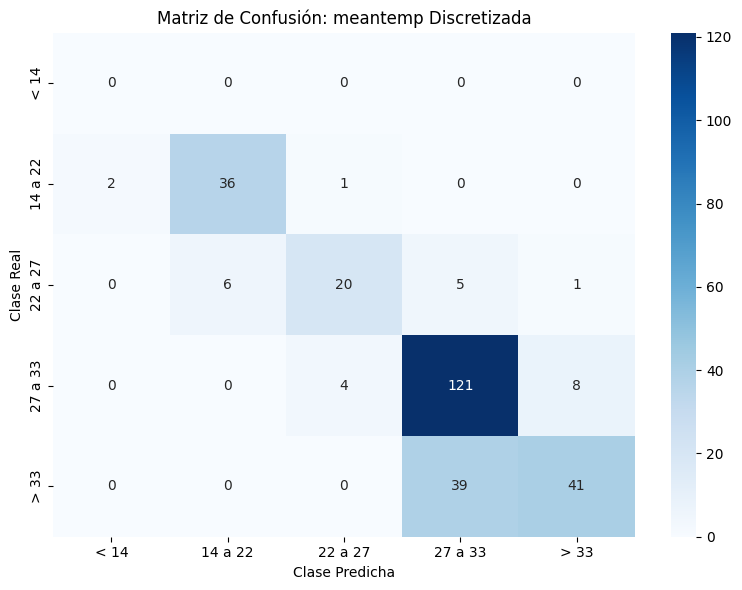

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Definición estricta de intervalos y etiquetas
# Intervalos: [-inf, 14), [14, 22), [22, 27), [27, 33), [33, inf)
bins = [-np.inf, 14, 22, 27, 33, np.inf]
class_names = ['< 14', '14 a 22', '22 a 27', '27 a 33', '> 33']
class_indices = list(range(len(class_names)))

# 2. Discretización a índices enteros (0 a 4)
y_true_binned = pd.cut(y_true, bins=bins, labels=False, right=False)
y_pred_binned = pd.cut(y_pred, bins=bins, labels=False, right=False)

# 3. Reporte de Clasificación
print("\n" + "="*60)
print("CLASSIFICATION REPORT (DISCRETIZADO DESDE REGRESIÓN)")
print("="*60)
print(classification_report(
    y_true_binned, 
    y_pred_binned, 
    labels=class_indices,
    target_names=class_names, 
    digits=4,
    zero_division=0
))

# 4. Matriz de Confusión
# Se especifica labels=class_indices para garantizar dimensiones 5x5 fijas
cm = confusion_matrix(y_true_binned, y_pred_binned, labels=class_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Matriz de Confusión: meantemp Discretizada')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.show()


### Evaluación en `DailyDelhiClimateTest.csv`

Para evaluar correctamente una serie temporal con ventana de retardo ($29$ lags) sin descartar datos:
1. **Lookback / Warm-up:** Se concatenan los últimos 29 días del set de entrenamiento (`df.tail(29)`) con `df_test` para que el primer día de prueba (`2017-01-01`) disponga de su ventana histórica completa, preservando los **114 días completos**.
2. **Limpieza física de sensor:** `DailyDelhiClimateTest.csv` contiene en su fila inicial una lectura corrupta de presión (`meanpressure = 59.0`). Se filtra con el rango físico $[950, 1050]\text{ hPa}$ e interpolación temporal.
3. **Transformación:** Se escala con el `scaler` ajustado en entrenamiento y se infiere con el mejor modelo.

In [42]:
# 1. Cargar archivo de prueba oficial
test_file = file_dict['DailyDelhiClimateTest']
df_test = pd.read_csv(test_file)
df_test['date'] = pd.to_datetime(df_test['date'])
df_test.set_index('date', inplace=True)
df_test.sort_index(inplace=True)

df_test.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-01-01,15.913043,85.869565,2.743478,59.000000
2017-01-02,18.500000,77.222222,2.894444,1018.277778
2017-01-03,17.111111,81.888889,4.016667,1018.333333
2017-01-04,18.700000,70.050000,4.545000,1015.700000
2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [43]:
# 2. Concatenar buffer histórico para calcular lags (29 días) y medias móviles (14 días)
raw_base_features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
df_test_combined = pd.concat([df[raw_base_features].tail(29 + 14), df_test[raw_base_features]])

df_test_combined.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2016-11-19,20.666667,60.666667,2.840000,1012.466667
2016-11-20,22.250000,59.900000,2.505000,1013.350000
2016-11-21,21.538462,60.461538,2.715385,1013.000000
2016-11-22,22.578947,50.157895,8.000000,1012.894737
2016-11-23,22.826087,51.434783,6.604348,1013.173913


In [44]:
display(df_test_combined['meanpressure'].describe())

# 3. Limpiar anomalía de meanpressure en test e interpolar
df_test_combined['meanpressure'] = df_test_combined['meanpressure'].mask(
    ~df_test_combined['meanpressure'].between(950, 1050)
).interpolate(method='time')

display(df_test_combined['meanpressure'].describe())

count     157.000000
mean     1007.200948
std        76.334107
min        59.000000
25%      1010.000000
50%      1014.295455
75%      1016.952381
max      1022.809524
Name: meanpressure, dtype: float64

count     157.000000
mean     1013.304061
std         5.165554
min       998.625000
25%      1010.200000
50%      1014.333333
75%      1017.045455
max      1022.809524
Name: meanpressure, dtype: float64

In [45]:
# 4. Aplicar ingeniería de variables a test combinado y generar matriz de lags
df_test_combined = engineer_weather_features(df_test_combined)
X_test_full = df_test_combined[features].shift(range(30)).dropna()
X_test_full = X_test_full.loc[df_test.index]  # Asegurar exactamente los 114 días de test

X_test_full.head()

,meantemp_0,humidity_0,wind_speed_0,meanpressure_0,apparent_temp_0,sin_doy_0,cos_doy_0,temp_diff_1_0,temp_diff_7_0,temp_ma_7_0,...,humidity_29,wind_speed_29,meanpressure_29,apparent_temp_29,sin_doy_29,cos_doy_29,temp_diff_1_29,temp_diff_7_29,temp_ma_7_29,temp_ma_14_29
date,,,,,,,,,,,,,,,,,,,,,
2017-01-01,15.913043,85.869565,2.743478,1017.188889,16.492236,0.017202,0.999852,0.860412,1.913043,15.929894,...,52.166667,5.866667,1019.333333,20.392460,-0.451786,0.892126,2.000000,-3.085784,21.105465,21.874780
2017-01-02,18.500000,77.222222,2.894444,1018.277778,19.351340,0.034398,0.999408,2.586957,1.357143,16.123771,...,55.250000,5.666667,1019.700000,17.769768,-0.436373,0.899766,-2.308333,-4.736364,20.428841,21.635494
2017-01-03,17.111111,81.888889,4.016667,1018.333333,17.591276,0.051584,0.998669,-1.388889,0.261111,16.161073,...,56.590909,4.952381,1017.045455,17.675026,-0.420831,0.907139,-0.263636,-3.818182,19.883387,21.428201
2017-01-04,18.700000,70.050000,4.545000,1015.700000,18.789314,0.068755,0.997634,1.588889,1.482609,16.372874,...,69.923077,2.503846,1017.961538,18.965804,-0.405165,0.914244,-0.097902,-3.072650,19.444437,21.139595
2017-01-05,18.388889,74.944444,3.300000,1014.333333,18.965271,0.085906,0.996303,-0.311111,3.150794,16.822988,...,74.350000,0.925000,1017.421053,19.201965,-0.389378,0.921078,-0.288462,-1.619565,19.213070,20.812732


In [48]:
# 5. Separar target continuo y matriz de predictores
y_test_real = X_test_full['meantemp_0'].to_numpy(dtype=np.float32)

# Conservar como DataFrame (float64) para evitar overflow en PowerTransformer
X_test_final = X_test_full.drop(columns=X_test_full.filter(regex='_0$').columns)

X_test_final.shape

(114, 319)

In [49]:
# Escalar en float64 y luego castear a float32 para PyTorch
X_test_scaled = scaler.transform(X_test_final).astype(np.float32)

X_test_scaled.shape

(114, 319)

In [50]:
# 6. Inferencia con el modelo de regresión entrenado (best_model)
best_model.eval()
device = next(best_model.parameters()).device
with torch.no_grad():
    x_tensor = torch.as_tensor(X_test_scaled, dtype=torch.float32, device=device)
    y_test_pred = best_model(x_tensor).view(-1).cpu().numpy()

y_test_pred.shape

(114,)

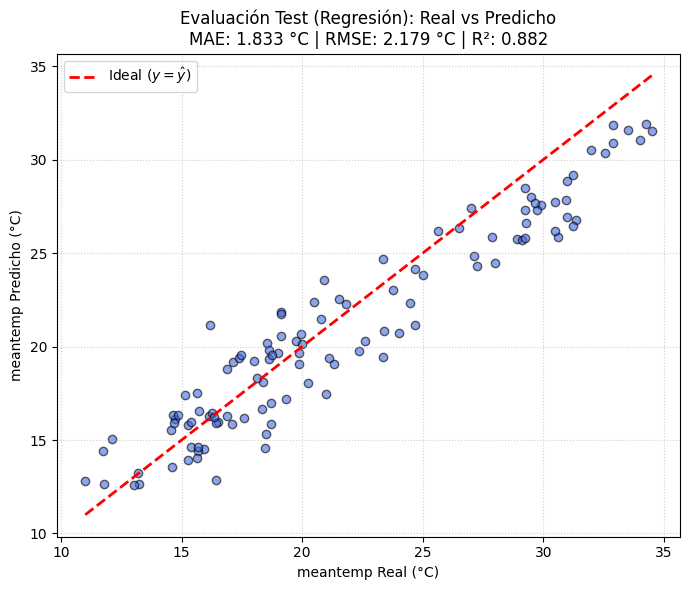

In [51]:
# 7. Gráfica: Scatter plot Real vs Predicho con diagonal ideal (Métricas de regresión)
mae_test = mean_absolute_error(y_test_real, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
r2_test = r2_score(y_test_real, y_test_pred)

plt.figure(figsize=(7, 6))
plt.scatter(y_test_real, y_test_pred, alpha=0.6, edgecolors='k', color='royalblue')
min_val = min(y_test_real.min(), y_test_pred.min())
max_val = max(y_test_real.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal ($y = \hat{y}$)')
plt.title(f'Evaluación Test (Regresión): Real vs Predicho\nMAE: {mae_test:.3f} °C | RMSE: {rmse_test:.3f} °C | R²: {r2_test:.3f}')
plt.xlabel('meantemp Real (°C)')
plt.ylabel('meantemp Predicho (°C)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

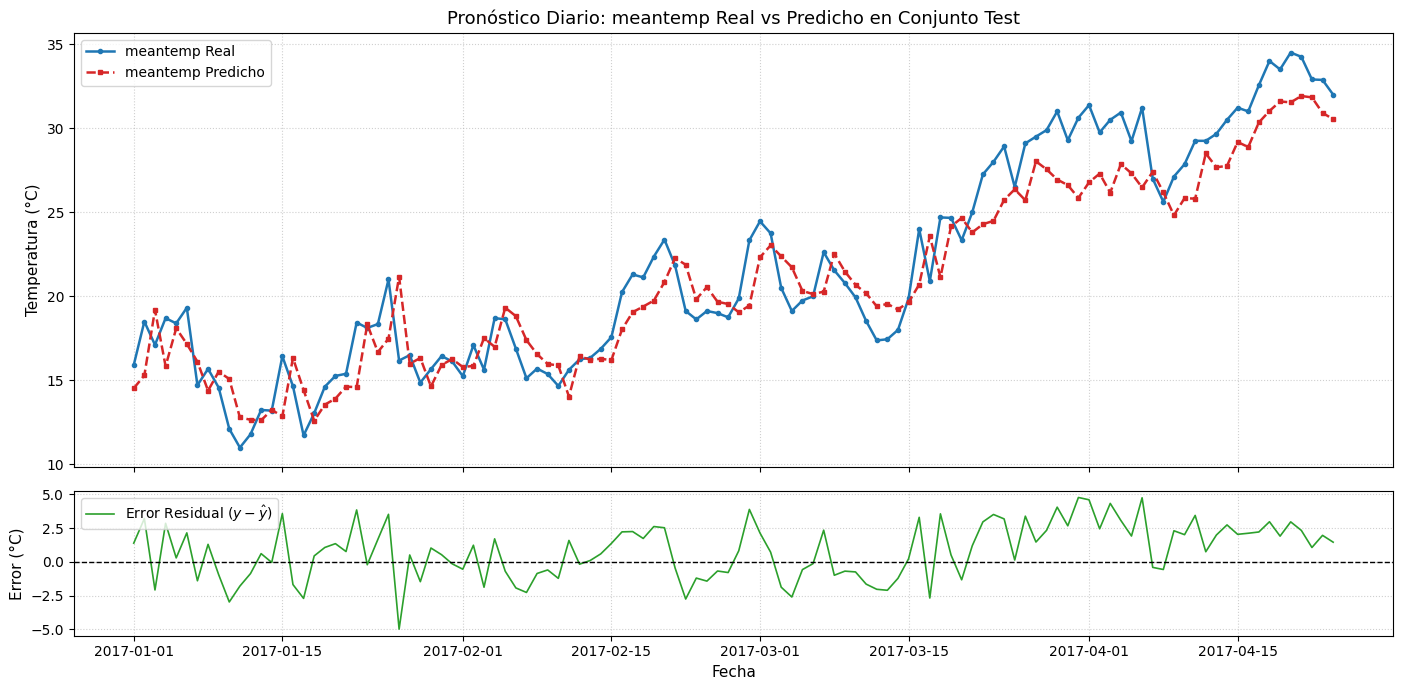

In [52]:
# 8. Gráfica: Series Temporales Real vs Predicho y Residuos
residuos_test = y_test_real - y_test_pred
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(X_test_full.index, y_test_real, label='meantemp Real', color='#1f77b4', lw=1.8, marker='o', markersize=3)
ax1.plot(X_test_full.index, y_test_pred, label='meantemp Predicho', color='#d62728', lw=1.8, linestyle='--', marker='s', markersize=3)
ax1.set_ylabel('Temperatura (°C)', fontsize=11)
ax1.set_title('Pronóstico Diario: meantemp Real vs Predicho en Conjunto Test', fontsize=13)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(X_test_full.index, residuos_test, color='#2ca02c', lw=1.2, label='Error Residual ($y - \hat{y}$)')
ax2.axhline(0, color='black', linestyle='--', lw=1)
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Error (°C)', fontsize=11)
ax2.legend(loc='upper left', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


REPORTE DE CLASIFICACIÓN OFICIAL (TEST: 114 DÍAS)
              precision    recall  f1-score   support

        < 14     0.6250    0.7143    0.6667         7
     14 a 22     0.8730    0.8871    0.8800        62
     22 a 27     0.2917    0.5385    0.3784        13
     27 a 33     0.7895    0.5357    0.6383        28
        > 33     0.0000    0.0000    0.0000         4

    accuracy                         0.7193       114
   macro avg     0.5158    0.5351    0.5127       114
weighted avg     0.7403    0.7193    0.7195       114



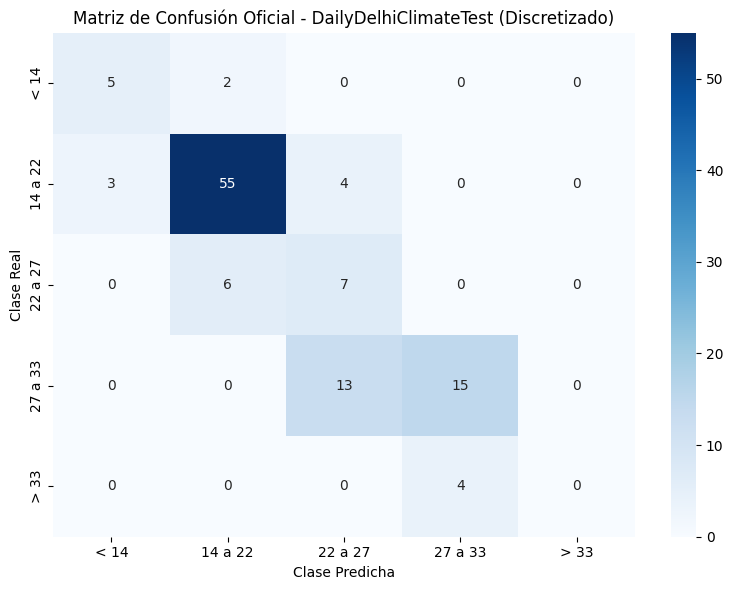

In [53]:
# 9. Discretización para Matriz de Confusión y Classification Report
bins = [-np.inf, 14, 22, 27, 33, np.inf]
class_names = ['< 14', '14 a 22', '22 a 27', '27 a 33', '> 33']
class_indices = list(range(len(class_names)))

y_test_binned = pd.cut(y_test_real, bins=bins, labels=False, right=False)
y_pred_binned = pd.cut(y_test_pred, bins=bins, labels=False, right=False)

print("\n" + "="*60)
print(f"REPORTE DE CLASIFICACIÓN OFICIAL (TEST: {len(y_test_real)} DÍAS)")
print("="*60)
print(classification_report(
    y_test_binned, 
    y_pred_binned, 
    labels=class_indices,
    target_names=class_names, 
    digits=4, 
    zero_division=0
))

cm_test = confusion_matrix(y_test_binned, y_pred_binned, labels=class_indices)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_test, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Matriz de Confusión Oficial - DailyDelhiClimateTest (Discretizado)')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.show()